### ROSALIA Paper I: Getting the Segments to simulate stray-light from the April2026 Mission Plan
First version: August 4, 2026. 

Alejandro S. Borlaff - NASA Ames Research Center. 
STA N245-312 - a.s.borlaff@nasa.gov


In [7]:
import os
import numpy as np
from tqdm import tqdm
import rosalia as rs
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord  # High-level coordinates
plt.style.use(os.path.dirname(rs.__file__) + "/style/nature_style.mplstyle")

In [37]:
def find_exposures_from_mission_plan(visit_id):
    """
    Find the exposures from the mission plan that correspond to a given segment ID.
    """    
    # row = mission_plan[mission_plan["visit-id"] == visit_id]

    program_id = visit_id[0:5]
    plan_id = visit_id[5:7]
    pass_id = visit_id[7:10]
    segment_id = visit_id[10:13]

    match program_id:
        case "00981":
            print("GPS")
            program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/981-gps-Feb26.sim.ecsv"
        case "00994":
            print("HLWAS")
            program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/994-hlwas-Feb26.sim.ecsv"
        case "00998":
            print("GBTDS")
            program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/998-gbtds-Feb26.sim.ecsv"
        case "00999":
            print("HLTDS")
            program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/999-hltds-Feb26.sim.ecsv"

    program_plan = pd.read_csv(program_plan_name, comment="#", sep="\s",skiprows=1)

    # Find the requested exposures. 
    program_plan = program_plan[program_plan["SEGMENT"] == int(segment_id)]
    program_plan = program_plan[program_plan["PLAN"] == int(plan_id)]
    program_plan = program_plan[program_plan["PASS"] == int(pass_id)]

    return(program_plan)


def pick_n_exposures_from_program_plan(n, mission_plan, program_plan, program_id):

    # Remove GRISM observations from analysis. 
    program_plan = program_plan[program_plan["BANDPASS"] != "GRISM"]
    program_plan = program_plan.reset_index(drop=True)

    ids = list(np.random.choice(program_plan.index, size=len(program_plan.index), replace=False))
    mission_visit_ids = []
    mission_plan_rows = []
    program_plan_ids = []
    count = 0 

    with tqdm(total = n) as pbar:
        while count < n:
            i = ids[count]
            mission_visit_id = program_id + str(program_plan.iloc[i]["PLAN"]).zfill(2) + str(program_plan.iloc[i]["PASS"]).zfill(3) + str(program_plan.iloc[i]["SEGMENT"]).zfill(3)
            mission_plan_row = mission_plan[mission_plan["visit-id"] == mission_visit_id]
        
            if len(mission_plan_row) == 0:
                print(mission_visit_id)
                ids.pop(count)
                print(program_plan.iloc[i])
                
            else: 
                count = count + 1 
                program_plan_ids.append(i)
                mission_visit_ids.append(mission_visit_id)
                mission_plan_rows.append(mission_plan_row)

            # print(count)
            pbar.update(1)

    mission_plan_rows = pd.concat(mission_plan_rows)

    # print(mission_plan_rows["assigned orient"])

    exposures_db = program_plan.loc[program_plan_ids]
    exposures_db = exposures_db.reset_index(drop=True)
    exposures_db["PA"] = np.array(mission_plan_rows["assigned orient"])

    # print(mission_visit_ids)
    exposures_db["MissionPlanID"] = mission_visit_ids

    return(exposures_db)


##### Let's select the segments to simulate from the Roman Mission Plan
We will use the Simulated_schedules from Apr2026_MissionPlan, in STScI BOX (POC: Gisela de Rosa)

In [38]:
mission_plan = pd.read_csv("/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/schedule-RD26075MP1-run_id_RD26075MP1_R26069HJROLLP1.csv",
                            dtype={"visit-id": str})

mission_plan = mission_plan[~np.isnan(mission_plan["assigned orient"])]

Text(0, 0.5, 'Dec [deg]')

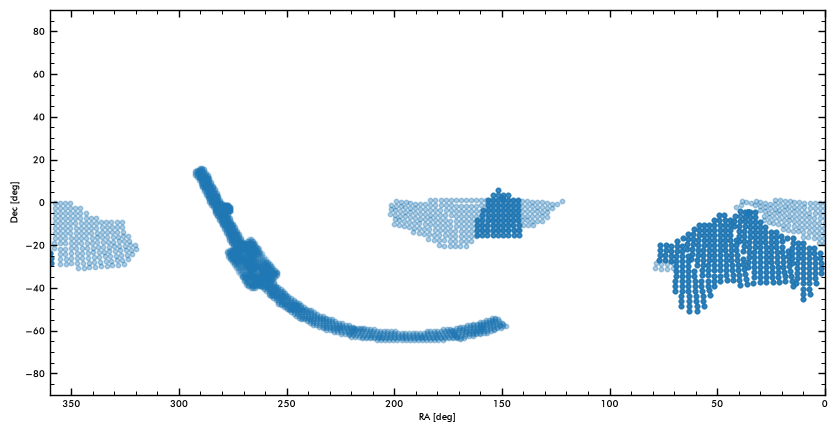

In [39]:
visit_coords = SkyCoord(np.rad2deg(mission_plan["ra"]), np.rad2deg(mission_plan["dec"]), frame="icrs", unit=(u.deg, u.deg))  # 3 coords

fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(visit_coords.ra, visit_coords.dec, s=10, alpha=0.2)
ax.set_ylim(-90, 90)
ax.set_xlim(360, 0)
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")

In [40]:
gps_program_id = "00981"
gps_program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/981-gps-Feb26.sim.ecsv"
gps_program_plan = pd.read_csv(gps_program_plan_name, comment="#", sep="\s", skiprows=1)

hlwas_program_id = "00994"
hlwas_program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/994-hlwas-Feb26.sim.ecsv"
hlwas_program_plan = pd.read_csv(hlwas_program_plan_name, comment="#", sep="\s", skiprows=1)

gbtds_program_id = "00998"
gbtds_program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/998-gbtds-Feb26.sim.ecsv"
gbtds_program_plan = pd.read_csv(gbtds_program_plan_name, comment="#", sep="\s", skiprows=1)

hltds_program_id = "00999"
hltds_program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/999-hltds-Feb26.sim.ecsv"
hltds_program_plan = pd.read_csv(hltds_program_plan_name, comment="#", sep="\s", skiprows=1)

In [41]:
hltds_program_plan

,RA,DEC,PA,BANDPASS,MA_TABLE_NUMBER,DURATION,PLAN,PASS,SEGMENT,OBSERVATION,VISIT,EXPOSURE,EXPOSURE_TIME,TARGET_NAME
242.897856,52.467151,0.0,F062,1001,122,1,1,1,1,1,1,60.08694,<no,name>
242.328393,52.667306,0.0,F062,1001,122,1,1,1,1,2,1,60.08694,<no,name>
241.753721,52.864789,0.0,F062,1001,122,1,1,1,1,3,1,60.08694,<no,name>
241.173859,53.059514,0.0,F062,1001,122,1,1,1,1,4,1,60.08694,<no,name>
240.588836,53.251394,0.0,F062,1001,122,1,1,1,1,5,1,60.08694,<no,name>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60.415688,-48.923967,0.0,F087,1013,255,1,320,1,8,12,1,192.91069,<no,name>
59.884583,-48.729785,0.0,F087,1013,255,1,320,1,8,13,1,192.91069,<no,name>
59.357512,-48.533176,0.0,F087,1013,255,1,320,1,8,14,1,192.91069,<no,name>
58.834498,-48.334218,0.0,F087,1013,255,1,320,1,8,15,1,192.91069,<no,name>


In [42]:
hltds_mission_exposures

,RA,DEC,PA,BANDPASS,MA_TABLE_NUMBER,DURATION,PLAN,PASS,SEGMENT,OBSERVATION,VISIT,EXPOSURE,EXPOSURE_TIME,TARGET_NAME,MissionPlanID
0,54.075599,0.0,NaN,1001,122,1,1,1,1,19,1,60.08694,<no,name>,0099901001001


In [46]:
gbtds_program_plan

,RA,DEC,PA,BANDPASS,MA_TABLE_NUMBER,DURATION,PLAN,PASS,SEGMENT,OBSERVATION,VISIT,EXPOSURE,EXPOSURE_TIME,TARGET_NAME
0,268.536405,-28.539337,90.6,F146,1002,137,1,1,1,1,1,1,66.41188,mosaic-tile3-00
1,268.305485,-28.884223,90.6,F146,1002,137,1,1,1,1,2,1,66.41188,mosaic-tile3-00
2,268.072958,-29.228722,90.6,F146,1002,137,1,1,1,1,3,1,66.41188,mosaic-tile3-00
3,267.838842,-29.572806,90.6,F146,1002,137,1,1,1,1,4,1,66.41188,mosaic-tile3-00
4,267.603154,-29.916446,90.6,F146,1002,137,1,1,1,1,5,1,66.41188,mosaic-tile3-00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318739,268.869918,-29.626341,0.0,F213,1002,127,1,104,10,2,1,1,66.41188,mosaic-tile3-00
318740,268.470676,-29.428136,0.0,F213,1002,127,1,104,10,2,2,1,66.41188,mosaic-tile3-00
318741,268.072958,-29.228722,0.0,F213,1002,127,1,104,10,2,3,1,66.41188,mosaic-tile3-00
318742,267.676779,-29.028155,0.0,F213,1002,127,1,104,10,2,4,1,66.41188,mosaic-tile3-00


In [45]:
hltds_program_plan

,RA,DEC,PA,BANDPASS,MA_TABLE_NUMBER,DURATION,PLAN,PASS,SEGMENT,OBSERVATION,VISIT,EXPOSURE,EXPOSURE_TIME,TARGET_NAME
242.897856,52.467151,0.0,F062,1001,122,1,1,1,1,1,1,60.08694,<no,name>
242.328393,52.667306,0.0,F062,1001,122,1,1,1,1,2,1,60.08694,<no,name>
241.753721,52.864789,0.0,F062,1001,122,1,1,1,1,3,1,60.08694,<no,name>
241.173859,53.059514,0.0,F062,1001,122,1,1,1,1,4,1,60.08694,<no,name>
240.588836,53.251394,0.0,F062,1001,122,1,1,1,1,5,1,60.08694,<no,name>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60.415688,-48.923967,0.0,F087,1013,255,1,320,1,8,12,1,192.91069,<no,name>
59.884583,-48.729785,0.0,F087,1013,255,1,320,1,8,13,1,192.91069,<no,name>
59.357512,-48.533176,0.0,F087,1013,255,1,320,1,8,14,1,192.91069,<no,name>
58.834498,-48.334218,0.0,F087,1013,255,1,320,1,8,15,1,192.91069,<no,name>


In [43]:
# Get the exposures 
n = 1000
gps_mission_exposures   = pick_n_exposures_from_program_plan(n=n, mission_plan=mission_plan, program_plan=gps_program_plan,   program_id=gps_program_id)
hlwas_mission_exposures = pick_n_exposures_from_program_plan(n=n, mission_plan=mission_plan, program_plan=hlwas_program_plan, program_id=hlwas_program_id)
gbtds_mission_exposures = pick_n_exposures_from_program_plan(n=n, mission_plan=mission_plan, program_plan=gbtds_program_plan, program_id=gbtds_program_id)
hltds_mission_exposures = pick_n_exposures_from_program_plan(n=n, mission_plan=mission_plan, program_plan=hltds_program_plan, program_id=hltds_program_id)

 29%|██▉       | 294/1000 [00:00<00:00, 1473.26it/s]

0098101061001
RA                    277.807943
DEC                    -2.077347
PA                           0.0
BANDPASS                    F158
MA_TABLE_NUMBER             1033
DURATION                    1028
PLAN                           1
PASS                          61
SEGMENT                        1
OBSERVATION                    4
VISIT                          1
EXPOSURE                       2
EXPOSURE_TIME          999.34062
TARGET_NAME        Deep+Spec_W40
Name: 21629, dtype: object
0098101066001
RA                              159.442553
DEC                              -59.15108
PA                                     0.0
BANDPASS                              F213
MA_TABLE_NUMBER                       1001
DURATION                               128
PLAN                                     1
PASS                                    66
SEGMENT                                  1
OBSERVATION                              1
VISIT                                   67
EXPOSURE  

 44%|████▍     | 442/1000 [00:00<00:00, 1292.73it/s]

0098101067001
RA                           281.718339
DEC                           -1.957343
PA                                  0.0
BANDPASS                           F184
MA_TABLE_NUMBER                    1001
DURATION                            128
PLAN                                  1
PASS                                 67
SEGMENT                               1
OBSERVATION                           3
VISIT                                49
EXPOSURE                              1
EXPOSURE_TIME                  60.08694
TARGET_NAME        TDS_W43_High-Cadence
Name: 22916, dtype: object
0098101066001
RA                              160.148163
DEC                             -59.369677
PA                                     0.0
BANDPASS                              F213
MA_TABLE_NUMBER                       1001
DURATION                               128
PLAN                                     1
PASS                                    66
SEGMENT                                  

 71%|███████   | 709/1000 [00:00<00:00, 1313.37it/s]

...

10058it [00:12, 820.03it/s]

0099979001006
RA                 52.864789
DEC                      0.0
PA                      F087
BANDPASS                1004
MA_TABLE_NUMBER          148
DURATION                   1
PLAN                      79
PASS                       1
SEGMENT                    6
OBSERVATION                5
VISIT                      1
EXPOSURE             85.3867
EXPOSURE_TIME            <no
TARGET_NAME            name>
Name: 12917, dtype: object
0099973001001
RA                 53.659804
DEC                      0.0
PA                      F062
BANDPASS                1001
MA_TABLE_NUMBER          122
DURATION                   1
PLAN                      73
PASS                       1
SEGMENT                    1
OBSERVATION                7
VISIT                      1
EXPOSURE            60.08694
EXPOSURE_TIME            <no
TARGET_NAME            name>
Name: 11928, dtype: object
00999147001002
RA                  55.73526
DEC                      0.0
PA                      F129
BAND

10143it [00:12, 794.38it/s]

0099916001001
RA                -49.178541
DEC                      0.0
PA                      F062
BANDPASS                1001
MA_TABLE_NUMBER          122
DURATION                   1
PLAN                      16
PASS                       1
SEGMENT                    1
OBSERVATION                1
VISIT                      1
EXPOSURE            60.08694
EXPOSURE_TIME            <no
TARGET_NAME            name>
Name: 4117, dtype: object
00999166001002
RA                 55.251798
DEC                      0.0
PA                      F106
BANDPASS                1005
MA_TABLE_NUMBER          157
DURATION                   1
PLAN                     166
PASS                       1
SEGMENT                    2
OBSERVATION               32
VISIT                      1
EXPOSURE            94.87411
EXPOSURE_TIME            <no
TARGET_NAME            name>
Name: 25533, dtype: object
00999208001001
RA                -46.257719
DEC                      0.0
PA                      F062
BAND

KeyboardInterrupt: 

In [ ]:
# Let's plot the location in the sky of the survey. 

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(HLWAS_77_coords.ra.value, HLWAS_77_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black", label="HWLAS pointing")
ax.scatter(HLWAS_167_coords.ra.value, HLWAS_167_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black")
ax.scatter(HLWAS_243_coords.ra.value, HLWAS_243_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black")

ax.set_xlabel("Right ascension (degrees)")
ax.set_ylabel("Declination (degrees)")
plt.legend(frameon=False)
plt.savefig("HWLAS_coords.png", dpi=300)
import numpy as np
median_ra = np.median(np.array(list(HLWAS_77_coords.ra.value) + list(HLWAS_167_coords.ra.value) + list(HLWAS_243_coords.ra.value)))
median_dec = np.median(np.array(list(HLWAS_77_coords.dec.value) + list(HLWAS_167_coords.dec.value) + list(HLWAS_243_coords.dec.value)))

HLWAS_median  = SkyCoord(median_ra, median_dec, frame="icrs", unit=(u.deg))  # 3 coords

# ax.scatter(HLWAS_median.ra.value, HLWAS_median.dec.value, alpha=1, marker="+", s=1000, color="red")


In [ ]:
# Let's simulate the stray-light on random positions across the survey. 

# First, we need to find the correct position angle for the images.  
# We can generate these easily using Romanisim 
# https://roman-crds.stsci.edu/static/users_guide/basic_use.html

prefix_name = "ROSALIA_HLWAS_SCA"
bandpass = "F146"

# A likely date to obtain the images 
from astropy.time import Time
date = Time('2027-06-21T00:00:00.0', format='isot', scale='utc')

# Let's focus on one group of images. HLWAS 77 degrees. 


PA_v3 = np.zeros(len(HLWAS_77_coords))

from tqdm import tqdm 
for i in tqdm(range(len(PA_v3))):
    PA_v3[i] = rs.telescopes.Roman.get_bestPA(ra=HLWAS_77_coords[i].ra.value, dec=HLWAS_77_coords[i].dec.value, mjd=date.mjd)


In [ ]:

###################################
# This step takes time
# We will run it on a if bracket to avoid re-running if the images are already on the disk.
############
import os
import glob 

for i in range(len(PA_v3)):
    ra = HLWAS_77_coords[i].ra.value
    dec = HLWAS_77_coords[i].dec.value
    pa = PA_v3[i]
    mjd = date.mjd
    bandpass="F129"
    exptime=600
    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, 
                                             PA=pa, date=date, prefix="HWLAS77_", bandpass=bandpass, 
                                             exptime=exptime, radius=1,
                                             g_mag_max=20)

In [ ]:
# Get the images from the HLWAS 
import glob
import os
import numpy as np
import rosalia as rs
HLWAS_stray_names = glob.glob("HWLAS77_WFI_F129_*_stray_drz_scaled.fits")
print(HLWAS_stray_names)

import matplotlib.pyplot as plt
from astropy.io import fits
i = 0 

fig, ax = plt.subplots(figsize=(5,4))

mu_all = np.array([])
for i in range(len(HLWAS_stray_names)):
#if True:
    fe = fits.open(HLWAS_stray_names[i])[1].data
    mu = rs.detectors.fe2mu(fe, telescope="Roman", instrument="WFI", filter_name="F129")

mu_all = np.concatenate([mu_all, mu.flatten()])

ax.hist(mu_all, alpha=0.5, linewidth=1.5, color="dodgerblue", edgecolor="black", bins=500, density=True)

ax.set_xlabel(r'HLWAS Stray-light surface brightness (mag arcsec$^{-2}$)')
ax.set_ylabel(r'Density')
ax.set_xlim(28.2, 29)
plt.savefig("HWLAS_straylight_hist.png", dpi=300)



In [ ]:


for i in range(len(HLWAS_stray_names)):
    fe2mu_png = rs.plots.make_stray_plot(input_name=HLWAS_stray_names[i],
                                         ext=1, mode="fe2mu",
                                         color_label = "Surface brightness (mag arcsec$^{-2}$)", 
                                         figsize=(7,6), cmap="RdYlBu",
                                         mu_vmin=28.0, 
                                         mu_vmax=29.0)
